In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

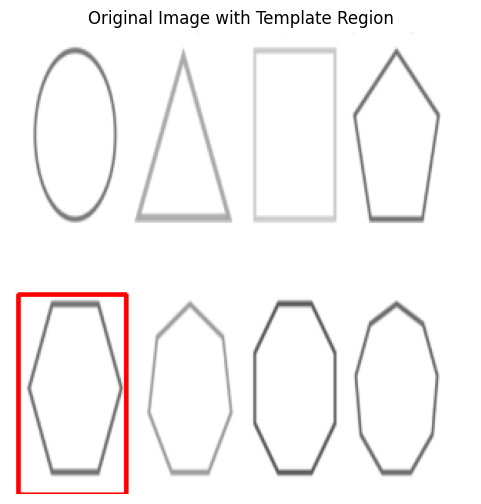

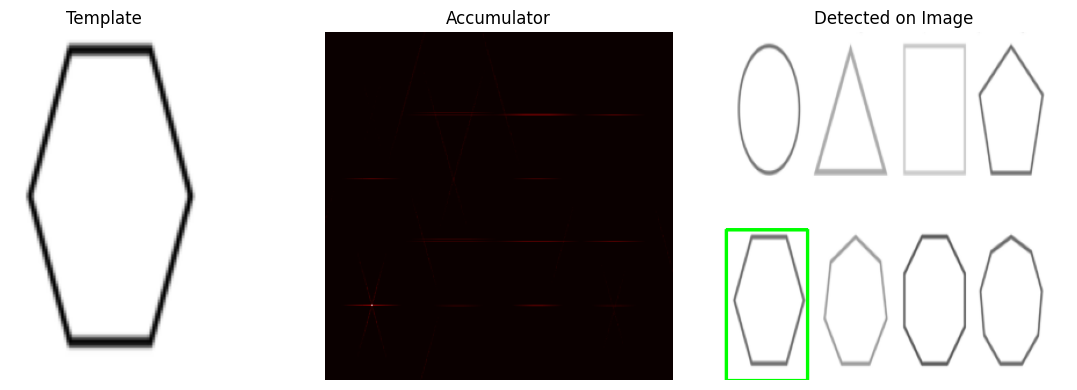

In [24]:



def load_images():
    img = cv2.imread(cv2.samples.findFile('shapes.png'), 0)
    img = cv2.resize(img, (300, 300))

    y1, y2 = 170, 300
    x1, x2 = 5,75
    template = img[y1:y2, x1:x2]
    ref_point = (template.shape[1] // 2, template.shape[0] // 2)


    vis_img = img.copy()
    vis_img_colored = cv2.cvtColor(vis_img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(vis_img_colored, (x1, y1), (x2, y2), (0, 0, 255), 2)

    plt.figure(figsize=(6, 6))
    plt.title("Original Image with Template Region")
    plt.imshow(vis_img_colored[..., ::-1])
    plt.axis('off')
    plt.show()

    return img, template, ref_point



def compute_orientation(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    orientation = np.arctan2(gy, gx)
    return orientation


def build_r_table(edges, orientation, ref_point):
    r_table = defaultdict(list)
    y_idx, x_idx = np.nonzero(edges)

    for x, y in zip(x_idx, y_idx):
        phi = orientation[y, x]
        dx = ref_point[0] - x
        dy = ref_point[1] - y
        r = np.sqrt(dx**2 + dy**2)
        theta = np.arctan2(dy, dx)
        r_table[round(phi, 2)].append((r, theta))

    return r_table

def apply_ght(target_edges, target_orient, r_table):
    h, w = target_edges.shape
    accumulator = np.zeros((h, w), dtype=np.uint64)
    y_idx, x_idx = np.nonzero(target_edges)

    for x, y in zip(x_idx, y_idx):
        phi = round(target_orient[y, x], 2)
        if phi in r_table:
            for r, theta in r_table[phi]:
                x0 = int(x + r * np.cos(theta))
                y0 = int(y + r * np.sin(theta))
                if 0 <= x0 < w and 0 <= y0 < h:
                    accumulator[y0, x0] += 1
    return accumulator

def visualize(img, template, accumulator):
    max_loc = np.unravel_index(np.argmax(accumulator), accumulator.shape)
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(overlay,
                  (max_loc[1] - template.shape[1]//2, max_loc[0] - template.shape[0]//2),
                  (max_loc[1] + template.shape[1]//2, max_loc[0] + template.shape[0]//2),
                  (0, 255, 0), 2)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Template")
    plt.imshow(template, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Accumulator")
    plt.imshow(accumulator, cmap='hot')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Detected on Image")
    plt.imshow(overlay[..., ::-1])
    plt.axis('off')
    plt.tight_layout()
    plt.show()


img, template, ref_point = load_images()
template_edges = cv2.Canny(template, 50, 150)
template_orient = compute_orientation(template)
r_table = build_r_table(template_edges, template_orient, ref_point)

target_edges = cv2.Canny(img, 50, 150)
target_orient = compute_orientation(img)
accumulator = apply_ght(target_edges, target_orient, r_table)

visualize(img, template, accumulator)


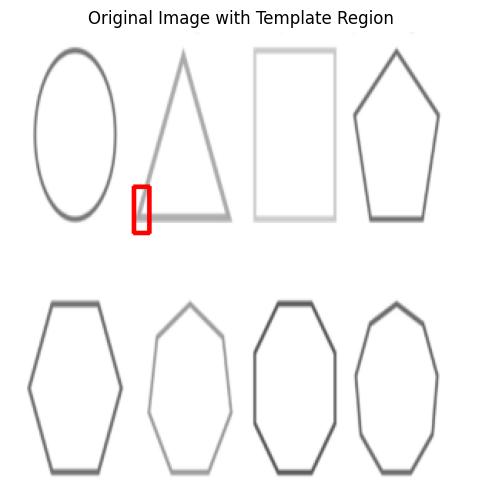

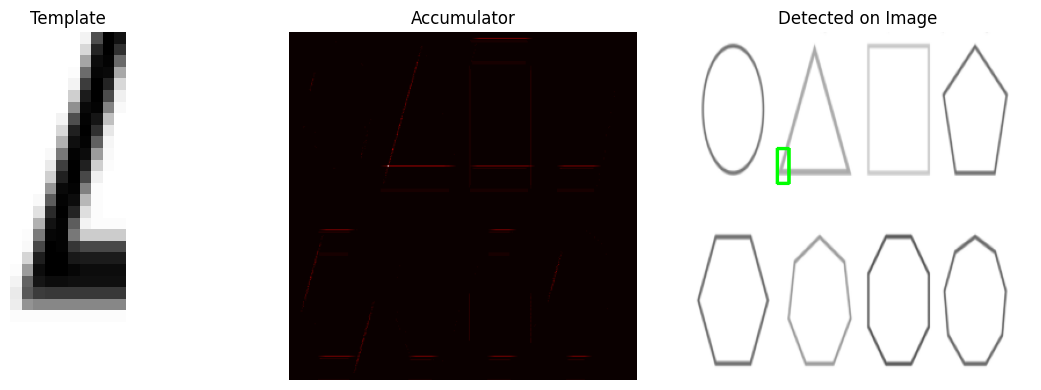

In [28]:



def load_images():
    img = cv2.imread(cv2.samples.findFile('shapes.png'), 0)
    img = cv2.resize(img, (300, 300))

    y1, y2 = 100, 130
    x1, x2 = 80,90
    template = img[y1:y2, x1:x2]
    ref_point = (template.shape[1] // 2, template.shape[0] // 2)


    vis_img = img.copy()
    vis_img_colored = cv2.cvtColor(vis_img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(vis_img_colored, (x1, y1), (x2, y2), (0, 0, 255), 2)

    plt.figure(figsize=(6, 6))
    plt.title("Original Image with Template Region")
    plt.imshow(vis_img_colored[..., ::-1])
    plt.axis('off')
    plt.show()

    return img, template, ref_point



def compute_orientation(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    orientation = np.arctan2(gy, gx)
    return orientation


def build_r_table(edges, orientation, ref_point):
    r_table = defaultdict(list)
    y_idx, x_idx = np.nonzero(edges)

    for x, y in zip(x_idx, y_idx):
        phi = orientation[y, x]
        dx = ref_point[0] - x
        dy = ref_point[1] - y
        r = np.sqrt(dx**2 + dy**2)
        theta = np.arctan2(dy, dx)
        r_table[round(phi, 2)].append((r, theta))

    return r_table

def apply_ght(target_edges, target_orient, r_table):
    h, w = target_edges.shape
    accumulator = np.zeros((h, w), dtype=np.uint64)
    y_idx, x_idx = np.nonzero(target_edges)

    for x, y in zip(x_idx, y_idx):
        phi = round(target_orient[y, x], 2)
        if phi in r_table:
            for r, theta in r_table[phi]:
                x0 = int(x + r * np.cos(theta))
                y0 = int(y + r * np.sin(theta))
                if 0 <= x0 < w and 0 <= y0 < h:
                    accumulator[y0, x0] += 1
    return accumulator

def visualize(img, template, accumulator):
    max_loc = np.unravel_index(np.argmax(accumulator), accumulator.shape)
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(overlay,
                  (max_loc[1] - template.shape[1]//2, max_loc[0] - template.shape[0]//2),
                  (max_loc[1] + template.shape[1]//2, max_loc[0] + template.shape[0]//2),
                  (0, 255, 0), 2)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Template")
    plt.imshow(template, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Accumulator")
    plt.imshow(accumulator, cmap='hot')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Detected on Image")
    plt.imshow(overlay[..., ::-1])
    plt.axis('off')
    plt.tight_layout()
    plt.show()


img, template, ref_point = load_images()
template_edges = cv2.Canny(template, 50, 150)
template_orient = compute_orientation(template)
r_table = build_r_table(template_edges, template_orient, ref_point)

target_edges = cv2.Canny(img, 50, 150)
target_orient = compute_orientation(img)
accumulator = apply_ght(target_edges, target_orient, r_table)

visualize(img, template, accumulator)


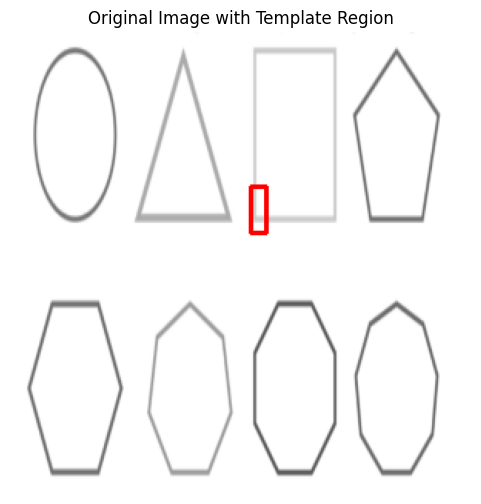

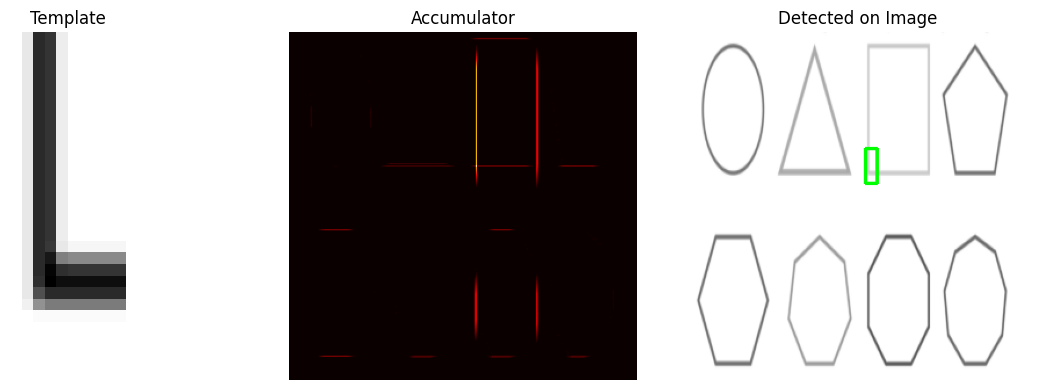

In [31]:



def load_images():
    img = cv2.imread(cv2.samples.findFile('shapes.png'), 0)
    img = cv2.resize(img, (300, 300))

    y1, y2 = 100, 130
    x1, x2 = 156,166
    template = img[y1:y2, x1:x2]
    ref_point = (template.shape[1] // 2, template.shape[0] // 2)


    vis_img = img.copy()
    vis_img_colored = cv2.cvtColor(vis_img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(vis_img_colored, (x1, y1), (x2, y2), (0, 0, 255), 2)

    plt.figure(figsize=(6, 6))
    plt.title("Original Image with Template Region")
    plt.imshow(vis_img_colored[..., ::-1])
    plt.axis('off')
    plt.show()

    return img, template, ref_point



def compute_orientation(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    orientation = np.arctan2(gy, gx)
    return orientation


def build_r_table(edges, orientation, ref_point):
    r_table = defaultdict(list)
    y_idx, x_idx = np.nonzero(edges)

    for x, y in zip(x_idx, y_idx):
        phi = orientation[y, x]
        dx = ref_point[0] - x
        dy = ref_point[1] - y
        r = np.sqrt(dx**2 + dy**2)
        theta = np.arctan2(dy, dx)
        r_table[round(phi, 2)].append((r, theta))

    return r_table

def apply_ght(target_edges, target_orient, r_table):
    h, w = target_edges.shape
    accumulator = np.zeros((h, w), dtype=np.uint64)
    y_idx, x_idx = np.nonzero(target_edges)

    for x, y in zip(x_idx, y_idx):
        phi = round(target_orient[y, x], 2)
        if phi in r_table:
            for r, theta in r_table[phi]:
                x0 = int(x + r * np.cos(theta))
                y0 = int(y + r * np.sin(theta))
                if 0 <= x0 < w and 0 <= y0 < h:
                    accumulator[y0, x0] += 1
    return accumulator

def visualize(img, template, accumulator):
    max_loc = np.unravel_index(np.argmax(accumulator), accumulator.shape)
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(overlay,
                  (max_loc[1] - template.shape[1]//2, max_loc[0] - template.shape[0]//2),
                  (max_loc[1] + template.shape[1]//2, max_loc[0] + template.shape[0]//2),
                  (0, 255, 0), 2)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Template")
    plt.imshow(template, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Accumulator")
    plt.imshow(accumulator, cmap='hot')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Detected on Image")
    plt.imshow(overlay[..., ::-1])
    plt.axis('off')
    plt.tight_layout()
    plt.show()


img, template, ref_point = load_images()
template_edges = cv2.Canny(template, 50, 150)
template_orient = compute_orientation(template)
r_table = build_r_table(template_edges, template_orient, ref_point)

target_edges = cv2.Canny(img, 50, 150)
target_orient = compute_orientation(img)
accumulator = apply_ght(target_edges, target_orient, r_table)

visualize(img, template, accumulator)
